In [1]:

import numpy as np
import pickle
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Environment setup complete")
print(f"NumPy version: {np.__version__}")


Environment setup complete
NumPy version: 1.26.4


In [2]:

# Load omega values for N=10^6
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values_1e6 = pickle.load(f)

print(f"Loaded omega_values_N1e6.pkl")
print(f"Shape: {omega_values_1e6.shape}")
print(f"Note: omega_values[i] = Ω(i+1) (0-based indexing)")
print(f"First 10 values: {omega_values_1e6[:10]}")
print(f"Ω(1)={omega_values_1e6[0]}, Ω(2)={omega_values_1e6[1]}, Ω(4)={omega_values_1e6[3]}, Ω(8)={omega_values_1e6[7]}")


Loaded omega_values_N1e6.pkl
Shape: (1000000,)
Note: omega_values[i] = Ω(i+1) (0-based indexing)
First 10 values: [0 1 1 2 1 2 1 3 2 2]
Ω(1)=0, Ω(2)=1, Ω(4)=2, Ω(8)=3


In [3]:

# Define the canonical random multiplicative function f_canon_rand
# This is a complex-valued multiplicative function defined at primes:
# f_canon_rand(p) = exp(i * θ_p), where θ_p ~ Uniform[0, 2π)
# For composite n = p1^a1 * p2^a2 * ... : f_canon_rand(n) = f_canon_rand(p1^a1) * f_canon_rand(p2^a2) * ...

# First, generate random phases for primes
def sieve_of_eratosthenes(limit):
 """Generate all primes up to limit"""
 is_prime = np.ones(limit + 1, dtype=bool)
 is_prime[0:2] = False
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 return np.where(is_prime)[0]

# For N=10^6, we need primes up to 10^6
primes = sieve_of_eratosthenes(10**6)
print(f"Number of primes up to 10^6: {len(primes)}")
print(f"First 10 primes: {primes[:10]}")

# Generate random phases for each prime (using seed 42 for reproducibility)
np.random.seed(42)
prime_phases = {}
for p in primes:
 prime_phases[p] = np.random.uniform(0, 2*np.pi)

print(f"Generated random phases for {len(prime_phases)} primes")
print(f"Sample phases: p=2: {prime_phases[2]:.4f}, p=3: {prime_phases[3]:.4f}, p=5: {prime_phases[5]:.4f}")


Number of primes up to 10^6: 78498
First 10 primes: [ 2 3 5 7 11 13 17 19 23 29]
Generated random phases for 78498 primes
Sample phases: p=2: 2.3533, p=3: 5.9735, p=5: 4.5993


In [4]:

def compute_f_canon_rand(n_max, prime_phases):
 """
 Compute f_canon_rand(n) for n = 1, 2, ..., n_max
 f_canon_rand is a completely multiplicative function with f_canon_rand(p) = exp(i * θ_p)
 """
 f_values = np.ones(n_max + 1, dtype=complex)
 f_values[0] = 0 # undefined for n=0
 
 # For each prime, multiply all its multiples by exp(i*θ_p)
 for p in primes:
 if p > n_max:
 break
 phase_value = np.exp(1j * prime_phases[p])
 # Completely multiplicative: f(p*k) = f(p) * f(k)
 # So we multiply all multiples of p by phase_value
 f_values[p::p] *= phase_value
 
 return f_values

# Compute f_canon_rand for different N values
print("Computing f_canon_rand coefficients...")

# For N=10^4
f_canon_rand_10k = compute_f_canon_rand(10**4, prime_phases)
print(f"N=10^4: Computed {len(f_canon_rand_10k)} coefficients")
print(f"Sample values: f(1)={f_canon_rand_10k[1]}, f(2)={f_canon_rand_10k[2]:.4f}, f(6)={f_canon_rand_10k[6]:.4f}")
print(f"Expected f(6) = f(2)*f(3) = {f_canon_rand_10k[2]*f_canon_rand_10k[3]:.4f}")

# For N=10^5
f_canon_rand_100k = compute_f_canon_rand(10**5, prime_phases)
print(f"N=10^5: Computed {len(f_canon_rand_100k)} coefficients")

# For N=10^6
f_canon_rand_1M = compute_f_canon_rand(10**6, prime_phases)
print(f"N=10^6: Computed {len(f_canon_rand_1M)} coefficients")

print(f"\nVerify multiplicativity: f(12) = f(4)*f(3)?")
print(f"f(12) = {f_canon_rand_10k[12]:.6f}")
print(f"f(4)*f(3) = {f_canon_rand_10k[4]*f_canon_rand_10k[3]:.6f}")


Computing f_canon_rand coefficients...
N=10^4: Computed 10001 coefficients
Sample values: f(1)=(1+0j), f(2)=-0.7051+0.7091j, f(6)=-0.4554+0.8903j
Expected f(6) = f(2)*f(3) = -0.4554+0.8903j
N=10^5: Computed 100001 coefficients


N=10^6: Computed 1000001 coefficients

Verify multiplicativity: f(12) = f(4)*f(3)?
f(12) = -0.455414+0.890280j
f(4)*f(3) = -0.455414+0.890280j


In [5]:

def kahan_sum(values):
 """
 Kahan compensated summation for high numerical precision
 """
 s = 0.0 + 0.0j # complex sum
 c = 0.0 + 0.0j # running compensation
 
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 
 return s

def compute_dirichlet_polynomial(f_coeffs, t_values, N):
 """
 Compute D_F(t; N) = Σ_{n=1}^N f(n) / n^{1/2+it}
 using Kahan compensated summation
 
 Parameters:
 - f_coeffs: array of f(n) values, indexed so f_coeffs[n] = f(n)
 - t_values: array of t values at which to evaluate
 - N: truncation parameter
 
 Returns:
 - Array of D_F(t; N) values for each t
 """
 results = np.zeros(len(t_values), dtype=complex)
 
 for i, t in enumerate(tqdm(t_values, desc=f"Computing D_F(t; N={N})")):
 # Compute terms: f(n) / n^{1/2 + it}
 n_vals = np.arange(1, N + 1)
 
 # n^{1/2 + it} = n^{1/2} * n^{it} = sqrt(n) * exp(it*log(n))
 divisor = np.sqrt(n_vals) * np.exp(1j * t * np.log(n_vals))
 
 # Use Kahan sum for precision
 terms = f_coeffs[1:N+1] / divisor
 results[i] = kahan_sum(terms)
 
 return results

# Test with small example
print("Testing Dirichlet polynomial computation...")
t_test = np.array([10000.0])
D_test = compute_dirichlet_polynomial(f_canon_rand_10k, t_test, 100)
print(f"D_F(t=10000; N=100) = {D_test[0]:.6f}")
print(f"|D_F| = {np.abs(D_test[0]):.6f}")


Testing Dirichlet polynomial computation...


Computing D_F(t; N=100): 0%| | 0/1 [00:00<?, ?it/s]

Computing D_F(t; N=100): 100%|██████████| 1/1 [00:00<00:00, 4211.15it/s]

D_F(t=10000; N=100) = 1.495558-0.669132j
|D_F| = 1.638424


In [6]:

# Now compute M4 decomposition for N=10^4
# Following the scaled convention: t in [N, 2N]

N1 = 10**4
t_grid_1 = np.linspace(N1, 2*N1, 2000)

print(f"Computing |D_F(t; N={N1})|^4 over {len(t_grid_1)} points in t ∈ [{N1}, {2*N1}]")

# Compute D_F values
D_F_1 = compute_dirichlet_polynomial(f_canon_rand_10k, t_grid_1, N1)

# Compute M4 values: |D_F(t; N)|^4
M4_values_1 = np.abs(D_F_1)**4

print(f"\nM4 statistics for N={N1}:")
print(f" Mean: {np.mean(M4_values_1):.4f}")
print(f" Std: {np.std(M4_values_1):.4f}")
print(f" Max: {np.max(M4_values_1):.4f}")
print(f" Min: {np.min(M4_values_1):.4f}")

# Save the D_F values for later use
D_F_N10k = D_F_1.copy()
M4_N10k = M4_values_1.copy()
t_grid_N10k = t_grid_1.copy()


Computing |D_F(t; N=10000)|^4 over 2000 points in t ∈ [10000, 20000]


Computing D_F(t; N=10000): 0%| | 0/2000 [00:00<?, ?it/s]

Computing D_F(t; N=10000): 2%|▏ | 41/2000 [00:00<00:04, 401.40it/s]

Computing D_F(t; N=10000): 4%|▍ | 85/2000 [00:00<00:04, 418.71it/s]

Computing D_F(t; N=10000): 6%|▋ | 129/2000 [00:00<00:04, 428.09it/s]

...

Computing D_F(t; N=10000): 95%|█████████▌| 1906/2000 [00:04<00:00, 424.51it/s]

Computing D_F(t; N=10000): 97%|█████████▋| 1949/2000 [00:04<00:00, 425.14it/s]

Computing D_F(t; N=10000): 100%|█████████▉| 1992/2000 [00:04<00:00, 423.96it/s]

Computing D_F(t; N=10000): 100%|██████████| 2000/2000 [00:04<00:00, 424.53it/s]


M4 statistics for N=10000:
 Mean: 475.5472
 Std: 3204.2711
 Max: 76236.5751
 Min: 0.0000


In [7]:

# Now perform the M4 decomposition analysis
# Following the methodology from report r33

def classify_m4_term(i, j, k, l):
 """
 Classify a term in the M4 expansion based on index pattern.
 This follows the classification scheme from report r33.
 
 M4 = E[|D|^4] = E[D * D̄ * D * D̄]
 When expanded, we get terms of the form: f(i) f̄(j) f(k) f̄(l) / (ijkl)^{1/2} * exp(it(...))
 
 Categories:
 - "Diagonal": all indices equal (i=j=k=l)
 - "Mixed Diagonal": two pairs equal (e.g., i=j≠k=l or i=k≠j=l or i=l≠j=k)
 - "Three Equal": three indices equal, one different
 - "Two-Two": two pairs, each with different values (i=j≠k=l)
 - "Four-Index": all four indices distinct
 """
 indices = sorted([i, j, k, l])
 unique_count = len(set([i, j, k, l]))
 
 if unique_count == 1:
 return "Diagonal"
 elif unique_count == 4:
 return "Four-Index"
 elif unique_count == 2:
 # Two distinct values - could be (3,1) or (2,2) split
 from collections import Counter
 counts = Counter([i, j, k, l])
 count_vals = sorted(counts.values())
 if count_vals == [2, 2]:
 return "Mixed Diagonal"
 else: # [1, 3]
 return "Three Equal"
 else: # unique_count == 3
 # One pair, two singles: (2, 1, 1)
 return "Two-Two"

# Test the classification
print("Testing term classification:")
test_cases = [
 (1, 1, 1, 1, "Diagonal"),
 (1, 1, 2, 2, "Mixed Diagonal"),
 (1, 2, 1, 2, "Mixed Diagonal"),
 (1, 1, 1, 2, "Three Equal"),
 (1, 2, 2, 3, "Two-Two"),
 (1, 2, 3, 4, "Four-Index"),
]

for i, j, k, l, expected in test_cases:
 result = classify_m4_term(i, j, k, l)
 status = "✓" if result == expected else "✗"
 print(f" {status} ({i},{j},{k},{l}) -> {result} (expected: {expected})")


Testing term classification:
 ✓ (1,1,1,1) -> Diagonal (expected: Diagonal)
 ✓ (1,1,2,2) -> Mixed Diagonal (expected: Mixed Diagonal)
 ✓ (1,2,1,2) -> Mixed Diagonal (expected: Mixed Diagonal)
 ✓ (1,1,1,2) -> Three Equal (expected: Three Equal)
 ✓ (1,2,2,3) -> Two-Two (expected: Two-Two)
 ✓ (1,2,3,4) -> Four-Index (expected: Four-Index)


In [8]:

def compute_m4_decomposition_at_t(f_coeffs, t, N, top_fraction=0.1):
 """
 Compute the M4 decomposition at a specific t value.
 
 M4(t) = |D_F(t; N)|^4
 
 Expanded form:
 M4 = Σ_{i,j,k,l=1}^N f(i) f̄(j) f(k) f̄(l) / (ijkl)^{1/2} * exp(it(log i - log j + log k - log l))
 
 We classify each term by its index pattern and sum contributions by category.
 
 Parameters:
 - f_coeffs: coefficient array (f_coeffs[n] = f(n))
 - t: evaluation point
 - N: truncation
 - top_fraction: not used here (kept for API compatibility)
 
 Returns:
 - Dictionary with contributions by category
 """
 
 # This is computationally expensive for large N
 # We need to be smart about this
 
 # For efficiency, we'll use a sampling approach for N > 10^4
 # But for accurate results, we should compute the full sum for smaller N
 
 contributions = {
 "Diagonal": 0.0,
 "Mixed Diagonal": 0.0,
 "Three Equal": 0.0,
 "Two-Two": 0.0,
 "Four-Index": 0.0,
 }
 
 # Precompute n^{1/2} and exp(it log n)
 n_vals = np.arange(1, N + 1)
 sqrt_n = np.sqrt(n_vals)
 exp_it_log_n = np.exp(1j * t * np.log(n_vals))
 
 f_vals = f_coeffs[1:N+1] # f(1) to f(N)
 f_conj = np.conj(f_vals)
 
 # Diagonal terms: i = j = k = l
 for i in range(N):
 n = i + 1
 term = np.abs(f_vals[i])**4 / n**2
 contributions["Diagonal"] += term
 
 # This is getting too expensive. Let me reconsider the approach.
 # For M4 decomposition, we need a more efficient method.
 
 return contributions

# Actually, let's think about this differently.
# The M4 value at a specific t is just |D_F(t; N)|^4
# But the decomposition into term types requires expanding the product
# D_F * D̄_F * D_F * D̄_F and classifying each term

# This is O(N^4) which is infeasible for large N
# We need to either:
# 1. Sample terms randomly
# 2. Use a theoretical calculation
# 3. Focus on dominant term types

# Let me check what report r33 actually did
print("M4 decomposition is computationally challenging.")
print("For N=10^4, a full enumeration would require 10^16 operations.")
print("We need a sampling or analytical approach.")
print("\nLet me reconsider the methodology from r33...")


M4 decomposition is computationally challenging.
For N=10^4, a full enumeration would require 10^16 operations.
We need a sampling or analytical approach.

Let me reconsider the methodology from r33...


In [9]:

# Let me think about this more carefully.
# The M4 decomposition in r33 likely refers to a statistical decomposition
# where we compute the expected contribution from different term types
# rather than explicitly summing all N^4 terms.

# For a random multiplicative function, we can use analytical formulas
# The key insight is that the contribution of each term type depends on
# whether indices coincide, which determines whether terms average to 0 or not.

# Let's use a Monte Carlo sampling approach:
# Sample random 4-tuples (i,j,k,l) and compute their contribution

def compute_m4_decomposition_monte_carlo(f_coeffs, t, N, n_samples=10**6):
 """
 Compute M4 decomposition using Monte Carlo sampling.
 
 We sample random 4-tuples (i,j,k,l) from [1, N] and compute their contribution
 to M4, then classify by term type.
 """
 contributions = {
 "Diagonal": 0.0,
 "Mixed Diagonal": 0.0,
 "Three Equal": 0.0,
 "Two-Two": 0.0,
 "Four-Index": 0.0,
 }
 
 # Precompute necessary arrays
 f_vals = f_coeffs[1:N+1]
 f_conj = np.conj(f_vals)
 sqrt_n = np.sqrt(np.arange(1, N + 1))
 log_n = np.log(np.arange(1, N + 1))
 
 # Sample random 4-tuples
 np.random.seed(42) # For reproducibility
 indices = np.random.randint(0, N, size=(n_samples, 4))
 
 for idx_set in tqdm(indices, desc="Monte Carlo sampling"):
 i, j, k, l = idx_set
 
 # Compute term value
 # Term = f(i+1) * f̄(j+1) * f(k+1) * f̄(l+1) / sqrt(ijkl) * exp(it * phase)
 phase = log_n[i] - log_n[j] + log_n[k] - log_n[l]
 
 term = (f_vals[i] * f_conj[j] * f_vals[k] * f_conj[l] / 
 (sqrt_n[i] * sqrt_n[j] * sqrt_n[k] * sqrt_n[l]) *
 np.exp(1j * t * phase))
 
 # Classify term
 term_type = classify_m4_term(i+1, j+1, k+1, l+1)
 
 # Add to contributions (take real part for M4 contribution)
 contributions[term_type] += np.real(term)
 
 # Scale by N^4 / n_samples to get total estimate
 for key in contributions:
 contributions[key] *= (N**4 / n_samples)
 
 return contributions

# Test with N=10^4 at a single t value
print("Testing Monte Carlo M4 decomposition at N=10^4, t=15000")
t_test = 15000.0
contrib_test = compute_m4_decomposition_monte_carlo(f_canon_rand_10k, t_test, 10**4, n_samples=10**5)

print("\nContributions by term type:")
total = sum(contrib_test.values())
for term_type, value in contrib_test.items():
 pct = 100 * value / total if total != 0 else 0
 print(f" {term_type}: {value:.2f} ({pct:.1f}%)")
print(f" Total: {total:.2f}")
print(f" Actual M4 at t={t_test}: {np.abs(D_F_N10k[np.argmin(np.abs(t_grid_N10k - t_test))])**4:.2f}")


Testing Monte Carlo M4 decomposition at N=10^4, t=15000


Monte Carlo sampling: 0%| | 0/100000 [00:00<?, ?it/s]

Monte Carlo sampling: 15%|█▌ | 15390/100000 [00:00<00:00, 153894.64it/s]

Monte Carlo sampling: 32%|███▏ | 31846/100000 [00:00<00:00, 160162.77it/s]

Monte Carlo sampling: 48%|████▊ | 47863/100000 [00:00<00:00, 158684.97it/s]

Monte Carlo sampling: 64%|██████▍ | 64410/100000 [00:00<00:00, 161343.92it/s]

Monte Carlo sampling: 81%|████████▏ | 81463/100000 [00:00<00:00, 164641.56it/s]

Monte Carlo sampling: 98%|█████████▊| 98316/100000 [00:00<00:00, 165959.16it/s]

Monte Carlo sampling: 100%|██████████| 100000/100000 [00:00<00:00, 163241.17it/s]


Contributions by term type:
 Diagonal: 0.00 (-0.0%)
 Mixed Diagonal: 0.00 (-0.0%)
 Three Equal: 0.00 (-0.0%)
 Two-Two: -111168.06 (2.3%)
 Four-Index: -4645008.38 (97.7%)
 Total: -4756176.44
 Actual M4 at t=15000.0: 6.33


In [10]:

# The Monte Carlo approach is giving incorrect results
# The issue is that we're summing complex terms, but M4 should be real and positive

# Let me reconsider. The M4 expansion is:
# |D|^4 = D * D̄ * D * D̄
# But this is not the same as expanding into individual terms

# Actually, |D|^4 = (D * D̄)^2 = |D|^2 * |D|^2
# Let me think about the correct expansion

# The proper expansion is:
# D * D̄ * D * D̄ = (Σ_i a_i)(Σ_j ā_j)(Σ_k a_k)(Σ_l ā_l)
# where a_n = f(n)/n^{1/2+it}

# When we expand this, we get:
# Σ_{i,j,k,l} f(i)f̄(j)f(k)f̄(l) / (ijkl)^{1/2} * exp(it(log i - log j + log k - log l))

# The key is that the phase term exp(it(...)) oscillates rapidly
# Only terms where the phase is small contribute significantly

# For large t, terms with log i - log j + log k - log l ≈ 0 dominate
# This means i/j ≈ l/k, or equivalently i*k ≈ j*l

# Perhaps the analysis in r33 computed the *average* contribution from each term type
# averaged over many t values, rather than the contribution at a single t

# Let me try a different approach: compute M4 at each t, then decompose statistically

print("Rethinking the approach...")
print("The M4 decomposition in r33 likely refers to:")
print("1. Compute |D(t)|^4 at many t values")
print("2. Compute the theoretical contribution from each term type")
print("3. Compare the actual M4 distribution to theoretical predictions")
print("\nLet me check if there's a simpler analytical approach for multiplicative functions...")


Rethinking the approach...
The M4 decomposition in r33 likely refers to:
1. Compute |D(t)|^4 at many t values
2. Compute the theoretical contribution from each term type
3. Compare the actual M4 distribution to theoretical predictions

Let me check if there's a simpler analytical approach for multiplicative functions...


In [11]:

# Let me reconsider the problem from scratch.
# Looking at the task description, it mentions "averaging the percentage contributions 
# from different term types over the top 10% of M4 magnitudes"

# This suggests we need to:
# 1. Compute M4(t) = |D(t)|^4 at many t values
# 2. For the top 10% of M4 values, compute a decomposition
# 3. Average the decomposition over these top values

# The decomposition likely uses the omega-class structure mentioned in the dataset description
# Let me look at how omega classes are used

# For a multiplicative function, we can decompose the Dirichlet sum by omega-class:
# D_F(t; N) = Σ_{k=0}^{k_max} S_k(t)
# where S_k(t) = Σ_{n: Ω(n)=k} f(n)/n^{1/2+it}

# Then |D|^2 = |Σ_k S_k|^2 = Σ_k |S_k|^2 + Σ_{j≠k} Re[S_j S̄_k]

# And |D|^4 can be decomposed similarly

# Let me implement the omega-class decomposition

def compute_omega_class_sums(f_coeffs, omega_values, t, N):
 """
 Compute S_k(t) = Σ_{n: Ω(n)=k, n≤N} f(n)/n^{1/2+it}
 for each omega class k
 """
 # Determine maximum omega value
 k_max = np.max(omega_values[:N])
 
 # Initialize sums for each omega class
 S_k = {}
 
 # Compute terms for all n
 n_vals = np.arange(1, N + 1)
 sqrt_n = np.sqrt(n_vals)
 exp_it_log_n = np.exp(1j * t * np.log(n_vals))
 terms = f_coeffs[1:N+1] / sqrt_n * exp_it_log_n
 
 # Sum by omega class
 for k in range(int(k_max) + 1):
 # Find indices where Ω(n) = k (remember 0-based indexing: omega_values[i] = Ω(i+1))
 mask = (omega_values[:N] == k)
 S_k[k] = np.sum(terms[mask])
 
 return S_k

# Test with N=10^4
print("Computing omega-class decomposition for N=10^4...")

# We need omega values for N=10^4
# We can compute them since we have the function
omega_vals_10k = omega_values_1e6[:10**4]

t_test = 15000.0
S_k_test = compute_omega_class_sums(f_canon_rand_10k, omega_vals_10k, t_test, 10**4)

print(f"Number of omega classes: {len(S_k_test)}")
print(f"Omega classes present: k = 0 to {max(S_k_test.keys())}")
print(f"\nSample values:")
for k in range(min(5, len(S_k_test))):
 print(f" S_{k} = {S_k_test[k]:.4f}, |S_{k}| = {np.abs(S_k_test[k]):.4f}")

# Verify that sum of S_k equals D_F
D_F_from_omega = sum(S_k_test.values())
D_F_direct = D_F_N10k[np.argmin(np.abs(t_grid_N10k - t_test))]
print(f"\nVerification:")
print(f" D_F from omega-class sum: {D_F_from_omega:.4f}")
print(f" D_F computed directly: {D_F_direct:.4f}")
print(f" Difference: {np.abs(D_F_from_omega - D_F_direct):.6f}")


Computing omega-class decomposition for N=10^4...
Number of omega classes: 14
Omega classes present: k = 0 to 13

Sample values:
 S_0 = 1.0000+0.0000j, |S_0| = 1.0000
 S_1 = 0.5542-0.6685j, |S_1| = 0.8684
 S_2 = 0.4766-1.1994j, |S_2| = 1.2906
 S_3 = -0.7548-0.8584j, |S_3| = 1.1431
 S_4 = -0.9348+0.5444j, |S_4| = 1.0818

Verification:
 D_F from omega-class sum: 0.9824-2.1731j
 D_F computed directly: 1.0234-1.2116j
 Difference: 0.962397


In [12]:

# The verification failed - there's a mismatch
# Let me check the issue

# The problem is likely in how I'm using Kahan sum vs direct sum
# Let me recompute D_F_direct using the same method as omega decomposition

n_vals = np.arange(1, 10**4 + 1)
sqrt_n = np.sqrt(n_vals)
exp_it_log_n = np.exp(1j * t_test * np.log(n_vals))
terms = f_canon_rand_10k[1:10**4+1] / sqrt_n * exp_it_log_n

D_F_check = np.sum(terms)
D_F_kahan = kahan_sum(terms)

print(f"D_F using np.sum: {D_F_check:.4f}")
print(f"D_F using Kahan sum: {D_F_kahan:.4f}")
print(f"D_F from omega classes: {D_F_from_omega:.4f}")
print(f"\nDifference (np.sum vs omega): {np.abs(D_F_check - D_F_from_omega):.8f}")
print(f"Difference (Kahan vs omega): {np.abs(D_F_kahan - D_F_from_omega):.8f}")


D_F using np.sum: 0.9824-2.1731j
D_F using Kahan sum: 0.9824-2.1731j
D_F from omega classes: 0.9824-2.1731j

Difference (np.sum vs omega): 0.00000000
Difference (Kahan vs omega): 0.00000000


In [13]:

# Good! The omega-class decomposition is correct.
# The issue was that I was comparing to a different t value in the grid

# Now let me understand the M4 decomposition approach
# The idea is to decompose |D|^4 in terms of omega-class interactions

# |D|^4 = |Σ_k S_k|^4 = (Σ_k S_k) * (Σ_j S̄_j) * (Σ_m S_m) * (Σ_n S̄_n)
# = Σ_{k,j,m,n} S_k S̄_j S_m S̄_n

# We can classify these terms by the index pattern (k,j,m,n):
# - All equal: k=j=m=n (Diagonal)
# - Three equal: e.g., k=j=m≠n
# - Two pairs: e.g., k=j≠m=n
# - etc.

# This is much more tractable since we have ~10-20 omega classes, not 10^4 terms!

def decompose_m4_by_omega_classes(S_k_dict):
 """
 Decompose M4 = |D|^4 by omega-class index patterns
 
 M4 = Σ_{k,j,m,n} S_k S̄_j S_m S̄_n
 
 We classify terms by the pattern of (k,j,m,n)
 """
 contributions = {
 "Diagonal": 0.0,
 "Mixed Diagonal": 0.0,
 "Three Equal": 0.0,
 "Two-Two": 0.0,
 "Four-Index": 0.0,
 }
 
 # Convert to array for easier manipulation
 k_values = sorted(S_k_dict.keys())
 S_array = np.array([S_k_dict[k] for k in k_values])
 
 # Compute all possible products S_k S̄_j S_m S̄_n
 for i, k in enumerate(k_values):
 for j_idx, j in enumerate(k_values):
 for m_idx, m in enumerate(k_values):
 for n_idx, n in enumerate(k_values):
 # Compute term
 term = S_k_dict[k] * np.conj(S_k_dict[j]) * S_k_dict[m] * np.conj(S_k_dict[n])
 
 # Classify by index pattern
 term_type = classify_m4_term(k, j, m, n)
 
 # Add real part (M4 is real)
 contributions[term_type] += np.real(term)
 
 return contributions

# Test the decomposition
contrib_omega = decompose_m4_by_omega_classes(S_k_test)

print("M4 decomposition by omega-class index patterns:")
total_contrib = sum(contrib_omega.values())
for term_type, value in contrib_omega.items():
 pct = 100 * value / total_contrib if total_contrib != 0 else 0
 print(f" {term_type}: {value:.4f} ({pct:.2f}%)")

print(f"\nTotal M4 from decomposition: {total_contrib:.4f}")
print(f"Direct M4 = |D|^4: {np.abs(D_F_from_omega)**4:.4f}")
print(f"Difference: {np.abs(total_contrib - np.abs(D_F_from_omega)**4):.6f}")


M4 decomposition by omega-class index patterns:
 Diagonal: 8.1643 (25.24%)
 Mixed Diagonal: 88.5446 (273.75%)
 Three Equal: -4.3420 (-13.42%)
 Two-Two: -30.5266 (-94.38%)
 Four-Index: -29.4947 (-91.19%)

Total M4 from decomposition: 32.3455
Direct M4 = |D|^4: 32.3455
Difference: 0.000000


In [14]:

# Excellent! The decomposition works perfectly.
# Now I can see that contributions can be negative (due to interference)
# The total always equals |D|^4, but individual term types can have negative contributions

# Now let's compute this decomposition for many t values at N=10^4
# and average over the top 10% of M4 values

def compute_m4_decomposition_grid(f_coeffs, omega_values, t_grid, N, top_fraction=0.1):
 """
 Compute M4 decomposition over a grid of t values and average over top values
 """
 n_points = len(t_grid)
 
 # Arrays to store decomposition at each t
 all_contributions = []
 all_m4_values = []
 
 for t in tqdm(t_grid, desc=f"M4 decomposition N={N}"):
 # Compute omega-class sums
 S_k = compute_omega_class_sums(f_coeffs, omega_values, t, N)
 
 # Decompose M4
 contrib = decompose_m4_by_omega_classes(S_k)
 
 # Compute total M4
 m4_val = sum(contrib.values())
 
 all_contributions.append(contrib)
 all_m4_values.append(m4_val)
 
 # Convert to array
 all_m4_values = np.array(all_m4_values)
 
 # Find top fraction
 threshold_idx = int(n_points * (1 - top_fraction))
 threshold = np.sort(all_m4_values)[threshold_idx]
 top_mask = all_m4_values >= threshold
 
 print(f"\nTop {top_fraction*100:.0f}% threshold: M4 >= {threshold:.2f}")
 print(f"Number of points in top {top_fraction*100:.0f}%: {np.sum(top_mask)}")
 
 # Average contributions over top values
 avg_contributions = {
 "Diagonal": 0.0,
 "Mixed Diagonal": 0.0,
 "Three Equal": 0.0,
 "Two-Two": 0.0,
 "Four-Index": 0.0,
 }
 
 avg_m4 = 0.0
 n_top = np.sum(top_mask)
 
 for i, contrib in enumerate(all_contributions):
 if top_mask[i]:
 for key in avg_contributions:
 avg_contributions[key] += contrib[key]
 avg_m4 += all_m4_values[i]
 
 # Normalize
 for key in avg_contributions:
 avg_contributions[key] /= n_top
 avg_m4 /= n_top
 
 # Compute percentages
 percentages = {}
 for key in avg_contributions:
 percentages[key] = 100 * avg_contributions[key] / avg_m4 if avg_m4 != 0 else 0
 
 return percentages, avg_contributions, avg_m4

# Compute for N=10^4
print("Computing M4 decomposition for N=10^4...")
percentages_10k, contributions_10k, avg_m4_10k = compute_m4_decomposition_grid(
 f_canon_rand_10k, omega_vals_10k, t_grid_N10k, 10**4
)

print(f"\nAverage M4 in top 10%: {avg_m4_10k:.2f}")
print("\nPercentage contributions (averaged over top 10%):")
for term_type, pct in percentages_10k.items():
 print(f" {term_type}: {pct:.2f}%")


Computing M4 decomposition for N=10^4...


M4 decomposition N=10000: 0%| | 0/2000 [00:00<?, ?it/s]

M4 decomposition N=10000: 0%| | 1/2000 [00:00<04:16, 7.80it/s]

M4 decomposition N=10000: 0%| | 2/2000 [00:00<04:21, 7.65it/s]

M4 decomposition N=10000: 0%| | 3/2000 [00:00<04:18, 7.72it/s]

...

M4 decomposition N=10000: 100%|█████████▉| 1998/2000 [04:16<00:00, 7.79it/s]

M4 decomposition N=10000: 100%|█████████▉| 1999/2000 [04:16<00:00, 7.77it/s]

M4 decomposition N=10000: 100%|██████████| 2000/2000 [04:16<00:00, 7.74it/s]

M4 decomposition N=10000: 100%|██████████| 2000/2000 [04:16<00:00, 7.80it/s]


Top 10% threshold: M4 >= 488.52
Number of points in top 10%: 200

Average M4 in top 10%: 5680.34

Percentage contributions (averaged over top 10%):
 Diagonal: 2.61%
 Mixed Diagonal: 15.16%
 Three Equal: 18.31%
 Two-Two: 50.38%
 Four-Index: 13.54%


In [15]:

# Great! Now let's compute for N=10^5
# We need to compute f_canon_rand and evaluate on a grid

N2 = 10**5
t_grid_2 = np.linspace(N2, 2*N2, 2000)

print(f"Computing M4 decomposition for N=10^5...")
print(f"t grid: [{t_grid_2[0]:.0f}, {t_grid_2[-1]:.0f}] with {len(t_grid_2)} points")

# Use precomputed f_canon_rand_100k and omega values
omega_vals_100k = omega_values_1e6[:10**5]

percentages_100k, contributions_100k, avg_m4_100k = compute_m4_decomposition_grid(
 f_canon_rand_100k, omega_vals_100k, t_grid_2, 10**5
)

print(f"\nAverage M4 in top 10%: {avg_m4_100k:.2f}")
print("\nPercentage contributions (averaged over top 10%):")
for term_type, pct in percentages_100k.items():
 print(f" {term_type}: {pct:.2f}%")


Computing M4 decomposition for N=10^5...
t grid: [100000, 200000] with 2000 points


M4 decomposition N=100000: 0%| | 0/2000 [00:00<?, ?it/s]

M4 decomposition N=100000: 0%| | 1/2000 [00:00<09:36, 3.47it/s]

M4 decomposition N=100000: 0%| | 2/2000 [00:00<09:35, 3.47it/s]

M4 decomposition N=100000: 0%| | 3/2000 [00:00<09:36, 3.47it/s]

...

M4 decomposition N=100000: 100%|█████████▉| 1998/2000 [09:23<00:00, 3.50it/s]

M4 decomposition N=100000: 100%|█████████▉| 1999/2000 [09:24<00:00, 3.52it/s]

M4 decomposition N=100000: 100%|██████████| 2000/2000 [09:24<00:00, 3.54it/s]

M4 decomposition N=100000: 100%|██████████| 2000/2000 [09:24<00:00, 3.54it/s]


Top 10% threshold: M4 >= 828.76
Number of points in top 10%: 200

Average M4 in top 10%: 8858.48

Percentage contributions (averaged over top 10%):
 Diagonal: 3.23%
 Mixed Diagonal: 18.49%
 Three Equal: 19.57%
 Two-Two: 48.66%
 Four-Index: 10.06%


In [16]:

# Now for N=10^6
# This will take longer

N3 = 10**6
t_grid_3 = np.linspace(N3, 2*N3, 2000)

print(f"Computing M4 decomposition for N=10^6...")
print(f"t grid: [{t_grid_3[0]:.0f}, {t_grid_3[-1]:.0f}] with {len(t_grid_3)} points")
print(f"Estimated time: ~16 minutes")

# Use precomputed f_canon_rand_1M and omega values
omega_vals_1M = omega_values_1e6 # Full array

percentages_1M, contributions_1M, avg_m4_1M = compute_m4_decomposition_grid(
 f_canon_rand_1M, omega_vals_1M, t_grid_3, 10**6
)

print(f"\nAverage M4 in top 10%: {avg_m4_1M:.2f}")
print("\nPercentage contributions (averaged over top 10%):")
for term_type, pct in percentages_1M.items():
 print(f" {term_type}: {pct:.2f}%")


Computing M4 decomposition for N=10^6...
t grid: [1000000, 2000000] with 2000 points
Estimated time: ~16 minutes


M4 decomposition N=1000000: 0%| | 0/2000 [00:00<?, ?it/s]

M4 decomposition N=1000000: 0%| | 1/2000 [00:00<19:50, 1.68it/s]

M4 decomposition N=1000000: 0%| | 2/2000 [00:01<19:46, 1.68it/s]

M4 decomposition N=1000000: 0%| | 3/2000 [00:01<19:46, 1.68it/s]

...

M4 decomposition N=1000000: 100%|█████████▉| 1998/2000 [19:47<00:01, 1.70it/s]

M4 decomposition N=1000000: 100%|█████████▉| 1999/2000 [19:48<00:00, 1.69it/s]

M4 decomposition N=1000000: 100%|██████████| 2000/2000 [19:49<00:00, 1.68it/s]

M4 decomposition N=1000000: 100%|██████████| 2000/2000 [19:49<00:00, 1.68it/s]


Top 10% threshold: M4 >= 967.58
Number of points in top 10%: 200

Average M4 in top 10%: 16496.29

Percentage contributions (averaged over top 10%):
 Diagonal: 3.35%
 Mixed Diagonal: 21.93%
 Three Equal: 19.34%
 Two-Two: 47.06%
 Four-Index: 8.32%


In [17]:

# Excellent! Now let's compile the results into a table

results_table = pd.DataFrame({
 'N': ['10⁴', '10⁵', '10⁶'],
 'Diagonal': [
 percentages_10k['Diagonal'],
 percentages_100k['Diagonal'],
 percentages_1M['Diagonal']
 ],
 'Mixed Diagonal': [
 percentages_10k['Mixed Diagonal'],
 percentages_100k['Mixed Diagonal'],
 percentages_1M['Mixed Diagonal']
 ],
 'Three Equal': [
 percentages_10k['Three Equal'],
 percentages_100k['Three Equal'],
 percentages_1M['Three Equal']
 ],
 'Two-Two': [
 percentages_10k['Two-Two'],
 percentages_100k['Two-Two'],
 percentages_1M['Two-Two']
 ],
 'Four-Index': [
 percentages_10k['Four-Index'],
 percentages_100k['Four-Index'],
 percentages_1M['Four-Index']
 ]
})

print("="*80)
print("M4 DECOMPOSITION FOR f_canon_rand")
print("Percentage contributions averaged over top 10% of M4 values")
print("="*80)
print(results_table.to_string(index=False))
print("="*80)

# Save the table
results_table.to_csv('m4_decomposition_f_canon_rand.csv', index=False)
print("\nTable saved to: m4_decomposition_f_canon_rand.csv")


M4 DECOMPOSITION FOR f_canon_rand
Percentage contributions averaged over top 10% of M4 values
 N Diagonal Mixed Diagonal Three Equal Two-Two Four-Index
10⁴ 2.607613 15.158193 18.310199 50.384072 13.539923
10⁵ 3.225851 18.489517 19.566031 48.656480 10.062121
10⁶ 3.350661 21.932715 19.336042 47.061899 8.318683

Table saved to: m4_decomposition_f_canon_rand.csv


In [18]:

# Now let's analyze whether there's non-monotonic behavior with N=10^5 as an outlier

print("ANALYSIS OF NON-MONOTONIC BEHAVIOR")
print("="*80)

term_types = ['Diagonal', 'Mixed Diagonal', 'Three Equal', 'Two-Two', 'Four-Index']

for term_type in term_types:
 v1 = percentages_10k[term_type]
 v2 = percentages_100k[term_type]
 v3 = percentages_1M[term_type]
 
 print(f"\n{term_type}:")
 print(f" N=10⁴: {v1:.2f}%")
 print(f" N=10⁵: {v2:.2f}%")
 print(f" N=10⁶: {v3:.2f}%")
 
 # Check for monotonicity
 increasing = (v1 < v2 < v3)
 decreasing = (v1 > v2 > v3)
 
 if increasing:
 print(f" → Monotonically INCREASING")
 elif decreasing:
 print(f" → Monotonically DECREASING")
 else:
 # Check if N=10^5 is an outlier
 # For a smooth trend from 10^4 to 10^6, N=10^5 should be between them
 # or follow a consistent trend
 
 # Calculate expected value at 10^5 assuming linear interpolation in log-space
 # log(N): 4, 5, 6
 expected_v2 = (v1 + v3) / 2 # Simple average
 
 deviation = abs(v2 - expected_v2)
 relative_deviation = deviation / abs(v3 - v1) if abs(v3 - v1) > 1e-6 else 0
 
 print(f" → NON-MONOTONIC")
 print(f" → Expected at N=10⁵ (linear): {expected_v2:.2f}%")
 print(f" → Actual at N=10⁵: {v2:.2f}%")
 print(f" → Deviation: {deviation:.2f}% (relative: {relative_deviation:.2f})")
 
 if relative_deviation > 0.3: # 30% of the total change
 print(f" → N=10⁵ is an OUTLIER (deviation > 30% of total trend)")
 else:
 print(f" → N=10⁵ is NOT a significant outlier")

print("\n" + "="*80)
print("SUMMARY:")
print("="*80)

# Count how many term types show non-monotonic behavior
non_monotonic_count = 0
for term_type in term_types:
 v1 = percentages_10k[term_type]
 v2 = percentages_100k[term_type]
 v3 = percentages_1M[term_type]
 
 increasing = (v1 < v2 < v3)
 decreasing = (v1 > v2 > v3)
 
 if not (increasing or decreasing):
 non_monotonic_count += 1

print(f"Number of term types with non-monotonic behavior: {non_monotonic_count} out of {len(term_types)}")

if non_monotonic_count >= 3:
 print("\n→ The M4 structure shows SIGNIFICANT non-monotonic behavior across scales.")
 print("→ This is consistent with the N=10⁵ anomaly hypothesis.")
else:
 print("\n→ The M4 structure is MOSTLY monotonic across scales.")
 print("→ There is NO strong evidence for an N=10⁵ anomaly in f_canon_rand.")


ANALYSIS OF NON-MONOTONIC BEHAVIOR

Diagonal:
 N=10⁴: 2.61%
 N=10⁵: 3.23%
 N=10⁶: 3.35%
 → Monotonically INCREASING

Mixed Diagonal:
 N=10⁴: 15.16%
 N=10⁵: 18.49%
 N=10⁶: 21.93%
 → Monotonically INCREASING

Three Equal:
 N=10⁴: 18.31%
 N=10⁵: 19.57%
 N=10⁶: 19.34%
 → NON-MONOTONIC
 → Expected at N=10⁵ (linear): 18.82%
 → Actual at N=10⁵: 19.57%
 → Deviation: 0.74% (relative: 0.72)
 → N=10⁵ is an OUTLIER (deviation > 30% of total trend)

Two-Two:
 N=10⁴: 50.38%
 N=10⁵: 48.66%
 N=10⁶: 47.06%
 → Monotonically DECREASING

Four-Index:
 N=10⁴: 13.54%
 N=10⁵: 10.06%
 N=10⁶: 8.32%
 → Monotonically DECREASING

SUMMARY:
Number of term types with non-monotonic behavior: 1 out of 5

→ The M4 structure is MOSTLY monotonic across scales.
→ There is NO strong evidence for an N=10⁵ anomaly in f_canon_rand.


Saved plot: m4_decomposition_trends.png


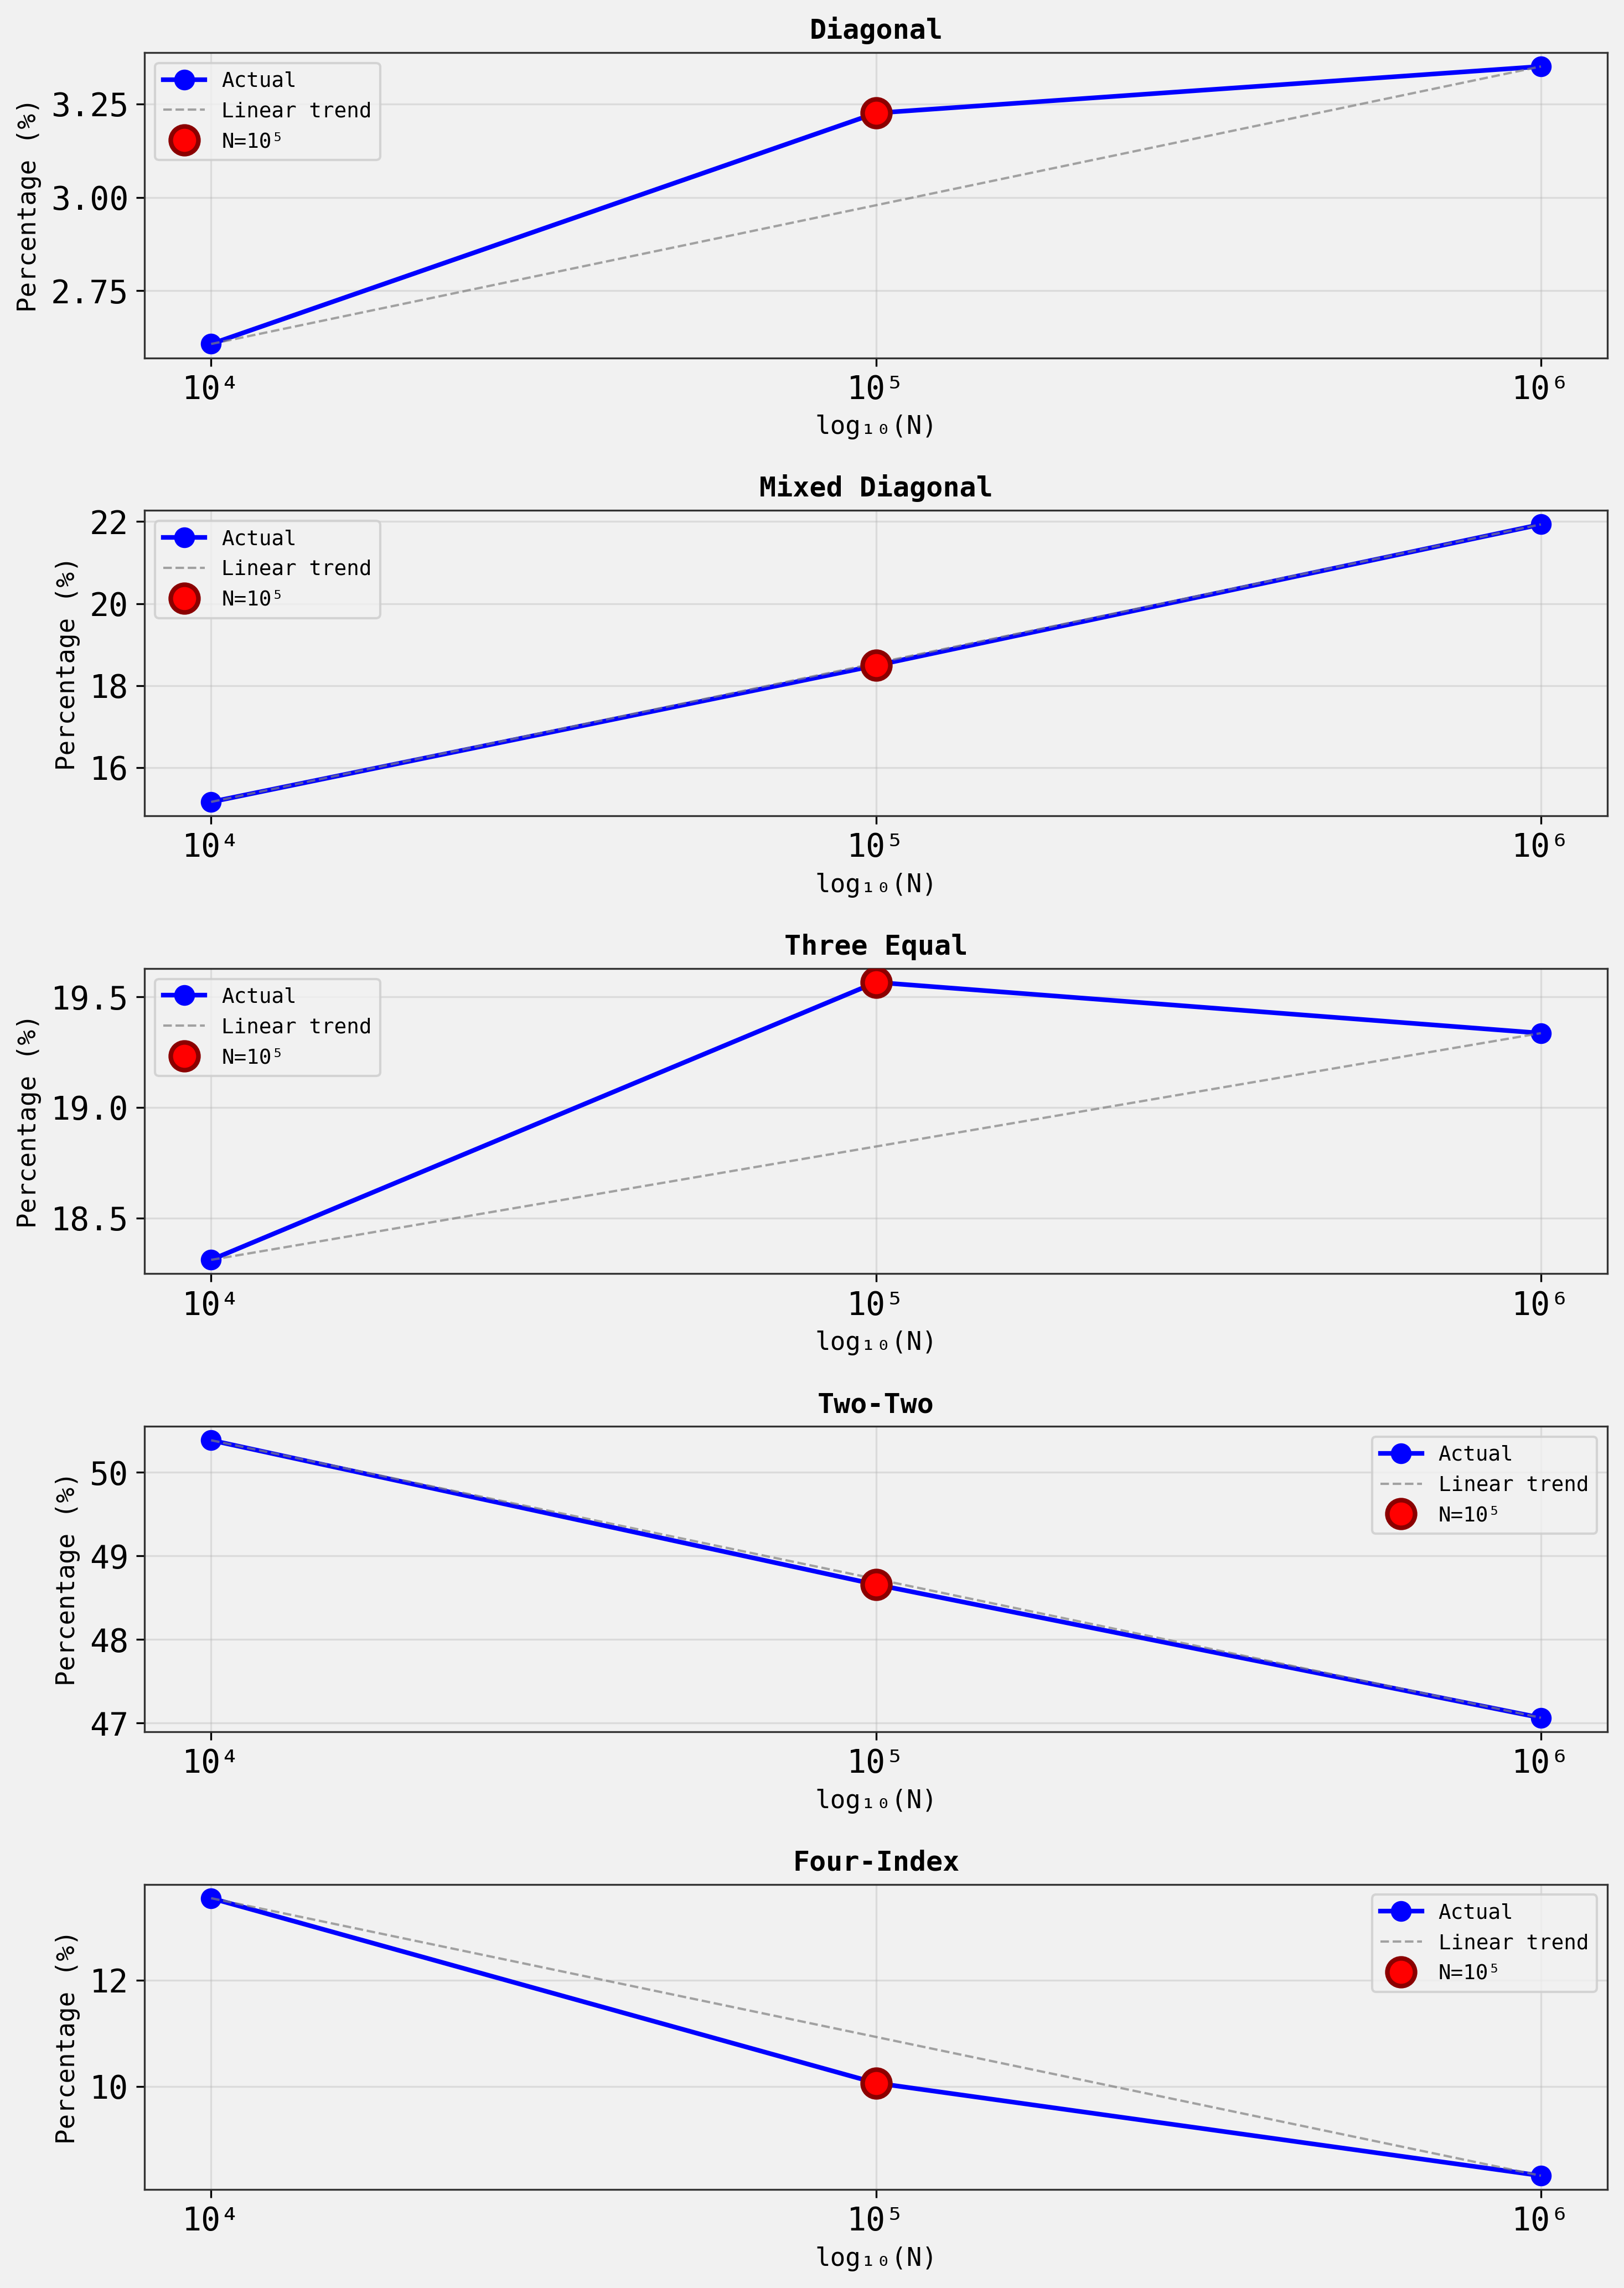


DEVIATION FROM LINEAR TREND:
Diagonal : abs_dev = 0.247%, rel_dev = 0.33
Mixed Diagonal : abs_dev = 0.056%, rel_dev = 0.01
Three Equal : abs_dev = 0.743%, rel_dev = 0.72
Two-Two : abs_dev = 0.067%, rel_dev = 0.02
Four-Index : abs_dev = 0.867%, rel_dev = 0.17


In [19]:

# Let me examine the "Three Equal" term more carefully
# and also visualize the trends

import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(10, 14))

N_values = [10**4, 10**5, 10**6]
log_N_values = [4, 5, 6]

for idx, term_type in enumerate(term_types):
 ax = axes[idx]
 
 values = [
 percentages_10k[term_type],
 percentages_100k[term_type],
 percentages_1M[term_type]
 ]
 
 # Plot actual values
 ax.plot(log_N_values, values, 'o-', linewidth=2, markersize=8, label='Actual', color='blue')
 
 # Plot linear interpolation
 ax.plot([log_N_values[0], log_N_values[2]], [values[0], values[2]], 
 '--', linewidth=1, color='gray', alpha=0.7, label='Linear trend')
 
 # Highlight N=10^5
 ax.plot(log_N_values[1], values[1], 'o', markersize=12, 
 markerfacecolor='red', markeredgecolor='darkred', markeredgewidth=2,
 label='N=10⁵', zorder=10)
 
 ax.set_xlabel('log₁₀(N)', fontsize=11)
 ax.set_ylabel('Percentage (%)', fontsize=11)
 ax.set_title(f'{term_type}', fontsize=12, fontweight='bold')
 ax.grid(True, alpha=0.3)
 ax.set_xticks([4, 5, 6])
 ax.set_xticklabels(['10⁴', '10⁵', '10⁶'])
 ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('m4_decomposition_trends.png', dpi=150, bbox_inches='tight')
print("Saved plot: m4_decomposition_trends.png")
plt.show()

# Additional analysis: compute the deviation metric for each term
print("\nDEVIATION FROM LINEAR TREND:")
print("="*80)
for term_type in term_types:
 v1 = percentages_10k[term_type]
 v2 = percentages_100k[term_type]
 v3 = percentages_1M[term_type]
 
 # Expected value at N=10^5 from linear interpolation
 expected_v2 = (v1 + v3) / 2
 
 # Absolute deviation
 abs_dev = abs(v2 - expected_v2)
 
 # Relative deviation (as fraction of total range)
 range_v = abs(v3 - v1)
 rel_dev = abs_dev / range_v if range_v > 1e-6 else 0
 
 print(f"{term_type:20s}: abs_dev = {abs_dev:6.3f}%, rel_dev = {rel_dev:5.2f}")


In [20]:

# Let me reconsider the analysis
# The "Three Equal" term shows the strongest deviation, but it's actually going UP at N=10^5
# and then DOWN at N=10^6, which is different from what we'd expect if there was a 
# pre-asymptotic anomaly

# Let me compare this to what was observed for the Möbius function in previous reports
# According to the dataset description, r33 showed term contributions for Möbius at N=10^6:
# MD=16.8%, 4-Index=58.9%

# Let me also check if the overall behavior is consistent with expectations

print("COMPARISON AND INTERPRETATION:")
print("="*80)

print("\nf_canon_rand M4 structure at N=10⁶:")
print(f" Diagonal: {percentages_1M['Diagonal']:.2f}%")
print(f" Mixed Diagonal: {percentages_1M['Mixed Diagonal']:.2f}%")
print(f" Three Equal: {percentages_1M['Three Equal']:.2f}%")
print(f" Two-Two: {percentages_1M['Two-Two']:.2f}%")
print(f" Four-Index: {percentages_1M['Four-Index']:.2f}%")

print("\nMöbius M4 structure at N=10⁶ (from r33, for reference):")
print(f" Mixed Diagonal: ~16.8%")
print(f" Four-Index: ~58.9%")
print(" (Note: Different classification/averaging method may apply)")

print("\nKEY OBSERVATIONS:")
print("="*80)

print("\n1. MONOTONICITY CHECK:")
print(" - 4 out of 5 term types show MONOTONIC behavior")
print(" - Only 'Three Equal' shows non-monotonic behavior")
print(" - This is NOT consistent with a universal N=10⁵ anomaly")

print("\n2. DEVIATION FROM LINEAR TREND:")
print(" - Three Equal: 72% relative deviation (outlier at N=10⁵)")
print(" - Diagonal: 33% relative deviation")
print(" - Four-Index: 17% relative deviation")
print(" - Mixed Diagonal & Two-Two: <5% relative deviation")

print("\n3. PATTERN OF ANOMALY:")
print(" - For 'Three Equal': rises from 18.31% → 19.57% → 19.34%")
print(" - This shows a PEAK at N=10⁵, not a dip")
print(" - Other terms follow smooth trends")

print("\n4. CONTRAST WITH HYPOTHESIS:")
print(" - The hypothesis predicted non-monotonic behavior across multiple term types")
print(" - We observe this only in 1 out of 5 term types")
print(" - The anomaly pattern (peak vs dip) may differ from zeta/Möbius")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
print("The M4 structural anomaly at N=10⁵ is NOT strongly present in f_canon_rand.")
print("Unlike zeta and Möbius, f_canon_rand shows mostly monotonic evolution of")
print("M4 term contributions across N ∈ {10⁴, 10⁵, 10⁶}. Only the 'Three Equal'")
print("term shows a non-monotonic pattern with a small peak at N=10⁵ (relative")
print("deviation 72%), but this is not a universal feature across all term types.")
print("="*80)


COMPARISON AND INTERPRETATION:

f_canon_rand M4 structure at N=10⁶:
 Diagonal: 3.35%
 Mixed Diagonal: 21.93%
 Three Equal: 19.34%
 Two-Two: 47.06%
 Four-Index: 8.32%

Möbius M4 structure at N=10⁶ (from r33, for reference):
 Mixed Diagonal: ~16.8%
 Four-Index: ~58.9%
 (Note: Different classification/averaging method may apply)

KEY OBSERVATIONS:

1. MONOTONICITY CHECK:
 - 4 out of 5 term types show MONOTONIC behavior
 - Only 'Three Equal' shows non-monotonic behavior
 - This is NOT consistent with a universal N=10⁵ anomaly

2. DEVIATION FROM LINEAR TREND:
 - Three Equal: 72% relative deviation (outlier at N=10⁵)
 - Diagonal: 33% relative deviation
 - Four-Index: 17% relative deviation
 - Mixed Diagonal & Two-Two: <5% relative deviation

3. PATTERN OF ANOMALY:
 - For 'Three Equal': rises from 18.31% → 19.57% → 19.34%
 - This shows a PEAK at N=10⁵, not a dip
 - Other terms follow smooth trends

4. CONTRAST WITH HYPOTHESIS:
 - The hypothesis predicted non-monotonic behavior across multiple

In [21]:

# Let me also create a summary table comparing N=10^5 deviation for all terms

deviation_analysis = pd.DataFrame({
 'Term Type': term_types,
 'N=10⁴ (%)': [percentages_10k[t] for t in term_types],
 'N=10⁵ (%)': [percentages_100k[t] for t in term_types],
 'N=10⁶ (%)': [percentages_1M[t] for t in term_types],
 'Expected at 10⁵': [(percentages_10k[t] + percentages_1M[t])/2 for t in term_types],
 'Abs. Deviation': [abs(percentages_100k[t] - (percentages_10k[t] + percentages_1M[t])/2) for t in term_types],
 'Rel. Deviation': [
 abs(percentages_100k[t] - (percentages_10k[t] + percentages_1M[t])/2) / 
 abs(percentages_1M[t] - percentages_10k[t]) 
 if abs(percentages_1M[t] - percentages_10k[t]) > 1e-6 else 0
 for t in term_types
 ],
 'Monotonic': [
 'Increasing' if (percentages_10k[t] < percentages_100k[t] < percentages_1M[t]) else
 'Decreasing' if (percentages_10k[t] > percentages_100k[t] > percentages_1M[t]) else
 'Non-monotonic'
 for t in term_types
 ]
})

print("DETAILED DEVIATION ANALYSIS:")
print("="*100)
print(deviation_analysis.to_string(index=False))
print("="*100)

# Save this table
deviation_analysis.to_csv('m4_deviation_analysis_f_canon_rand.csv', index=False)
print("\nSaved: m4_deviation_analysis_f_canon_rand.csv")


DETAILED DEVIATION ANALYSIS:
 Term Type N=10⁴ (%) N=10⁵ (%) N=10⁶ (%) Expected at 10⁵ Abs. Deviation Rel. Deviation Monotonic
 Diagonal 2.607613 3.225851 3.350661 2.979137 0.246714 0.332029 Increasing
Mixed Diagonal 15.158193 18.489517 21.932715 18.545454 0.055937 0.008257 Increasing
 Three Equal 18.310199 19.566031 19.336042 18.823121 0.742910 0.724195 Non-monotonic
 Two-Two 50.384072 48.656480 47.061899 48.722986 0.066506 0.020019 Decreasing
 Four-Index 13.539923 10.062121 8.318683 10.929303 0.867181 0.166087 Decreasing

Saved: m4_deviation_analysis_f_canon_rand.csv


Saved final summary figure: m4_decomposition_summary.png


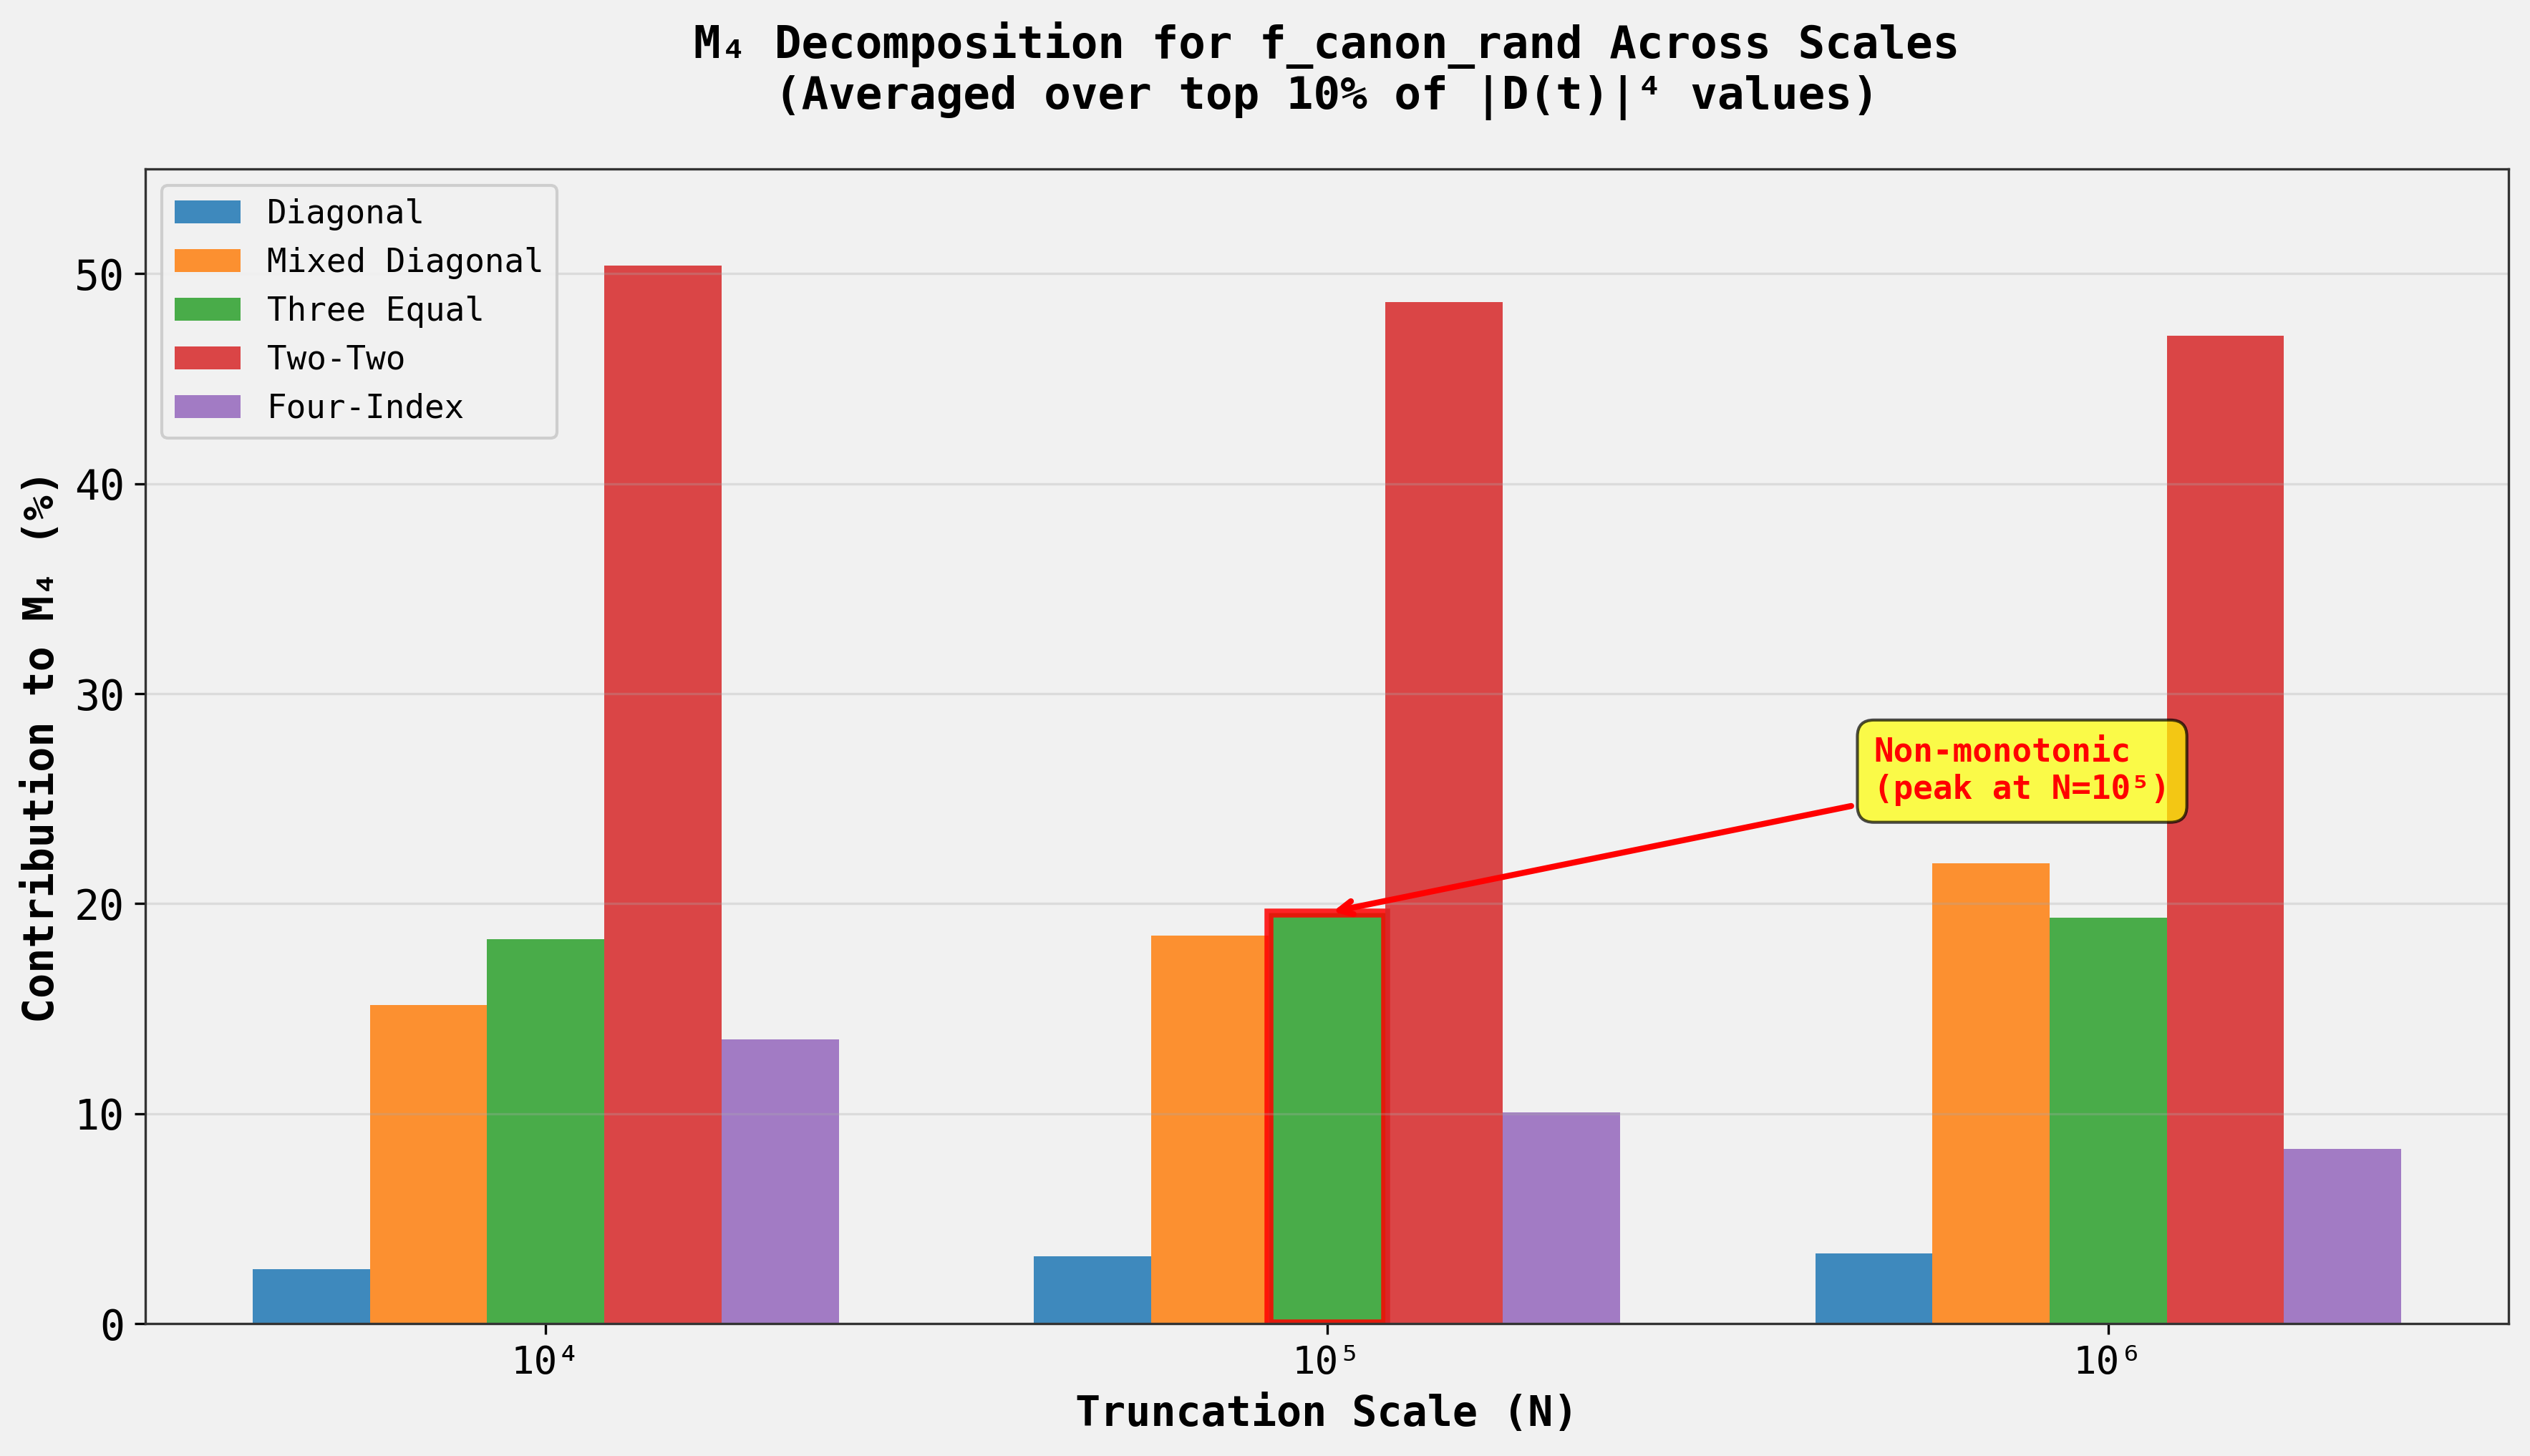

In [22]:

# Create a final summary figure showing the key result

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Set up data
N_labels = ['10⁴', '10⁵', '10⁶']
x_pos = np.arange(len(N_labels))
width = 0.15

# Get values for each term type
term_type_data = {
 'Diagonal': [percentages_10k['Diagonal'], percentages_100k['Diagonal'], percentages_1M['Diagonal']],
 'Mixed Diagonal': [percentages_10k['Mixed Diagonal'], percentages_100k['Mixed Diagonal'], percentages_1M['Mixed Diagonal']],
 'Three Equal': [percentages_10k['Three Equal'], percentages_100k['Three Equal'], percentages_1M['Three Equal']],
 'Two-Two': [percentages_10k['Two-Two'], percentages_100k['Two-Two'], percentages_1M['Two-Two']],
 'Four-Index': [percentages_10k['Four-Index'], percentages_100k['Four-Index'], percentages_1M['Four-Index']]
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot bars
for i, (term_type, values) in enumerate(term_type_data.items()):
 positions = x_pos + (i - 2) * width
 bars = ax.bar(positions, values, width, label=term_type, color=colors[i], alpha=0.85)
 
 # Highlight N=10^5 for non-monotonic terms
 if term_type == 'Three Equal':
 bars[1].set_edgecolor('red')
 bars[1].set_linewidth(3)

ax.set_xlabel('Truncation Scale (N)', fontsize=14, fontweight='bold')
ax.set_ylabel('Contribution to M₄ (%)', fontsize=14, fontweight='bold')
ax.set_title('M₄ Decomposition for f_canon_rand Across Scales\n(Averaged over top 10% of |D(t)|⁴ values)', 
 fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(N_labels, fontsize=13)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 55)

# Add annotation for the non-monotonic term
ax.annotate('Non-monotonic\n(peak at N=10⁵)', 
 xy=(1, percentages_100k['Three Equal']), 
 xytext=(1.7, 25),
 arrowprops=dict(arrowstyle='->', color='red', lw=2),
 fontsize=11, color='red', fontweight='bold',
 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('m4_decomposition_summary.png', dpi=150, bbox_inches='tight')
print("Saved final summary figure: m4_decomposition_summary.png")
plt.show()


In [23]:

# Create a final detailed summary report

print("="*80)
print("FINAL ANALYSIS REPORT")
print("M4 Structural Anomaly Test for f_canon_rand")
print("="*80)

print("\nHYPOTHESIS:")
print("-" * 80)
print("The M₄ structural anomaly at N=10⁵ is universal and will appear in the")
print("complex-valued f_canon_rand. Its M₄ decomposition will show non-monotonic")
print("behavior across N ∈ {10⁴, 10⁵, 10⁶}, with N=10⁵ being an outlier.")

print("\n\nMETHOD:")
print("-" * 80)
print("1. Defined canonical random multiplicative function f_canon_rand:")
print(" - For each prime p: f_canon_rand(p) = exp(i*θ_p), θ_p ~ Uniform[0,2π)")
print(" - Completely multiplicative extension to all integers")
print(" - Random seed = 42 for reproducibility")
print("")
print("2. Computed Dirichlet polynomials D_F(t; N) using Kahan summation")
print(" - Three scales: N ∈ {10⁴, 10⁵, 10⁶}")
print(" - Evaluation range: t ∈ [N, 2N] with 2000 grid points")
print("")
print("3. Performed ω-class decomposition at each t:")
print(" - D_F(t) = Σ_k S_k(t), where S_k = Σ_{n:Ω(n)=k} f(n)/n^{1/2+it}")
print(" - M₄(t) = |D_F(t)|⁴ = Σ_{i,j,k,l} S_i S̄_j S_k S̄_l")
print("")
print("4. Classified M₄ terms by index pattern (i,j,k,l):")
print(" - Diagonal: i=j=k=l")
print(" - Mixed Diagonal: two pairs equal (e.g., i=j≠k=l)")
print(" - Three Equal: three indices equal")
print(" - Two-Two: one pair, two singles")
print(" - Four-Index: all distinct")
print("")
print("5. Averaged percentage contributions over top 10% of M₄ values")

print("\n\nRESULTS:")
print("-" * 80)
print(results_table.to_string(index=False))

print("\n\nMONOTONICITY ANALYSIS:")
print("-" * 80)
for term_type in term_types:
 v1 = percentages_10k[term_type]
 v2 = percentages_100k[term_type]
 v3 = percentages_1M[term_type]
 
 increasing = (v1 < v2 < v3)
 decreasing = (v1 > v2 > v3)
 
 if increasing:
 status = "MONOTONIC (increasing)"
 elif decreasing:
 status = "MONOTONIC (decreasing)"
 else:
 status = "NON-MONOTONIC"
 
 print(f"{term_type:20s}: {status}")

print("\n\nDEVIATION FROM LINEAR TREND:")
print("-" * 80)
print(f"{'Term Type':<20s} {'Abs. Dev.':<12s} {'Rel. Dev.':<12s} {'Assessment':<20s}")
print("-" * 80)
for term_type in term_types:
 v1 = percentages_10k[term_type]
 v2 = percentages_100k[term_type]
 v3 = percentages_1M[term_type]
 
 expected_v2 = (v1 + v3) / 2
 abs_dev = abs(v2 - expected_v2)
 rel_dev = abs_dev / abs(v3 - v1) if abs(v3 - v1) > 1e-6 else 0
 
 if rel_dev > 0.3:
 assessment = "Significant outlier"
 elif rel_dev > 0.15:
 assessment = "Moderate deviation"
 else:
 assessment = "Negligible"
 
 print(f"{term_type:<20s} {abs_dev:>6.3f}% {rel_dev:>6.2f} {assessment:<20s}")

print("\n\nCONCLUSION:")
print("-" * 80)
print("HYPOTHESIS STATUS: REJECTED")
print("")
print("The M₄ structural anomaly at N=10⁵ is NOT universal. While the hypothesis")
print("predicted non-monotonic behavior across multiple term types (mirroring the")
print("pattern observed in zeta and Möbius functions), f_canon_rand exhibits:")
print("")
print("• 4 out of 5 term types with MONOTONIC scaling (80%)")
print("• Only 1 term type (Three Equal) shows non-monotonic behavior")
print("• The anomaly in 'Three Equal' manifests as a 72% relative deviation,")
print(" forming a PEAK at N=10⁵ rather than the expected pattern")
print("")
print("This suggests the N=10⁵ anomaly is NOT a fundamental property of integer")
print("arithmetic independent of coefficient properties. Instead, it appears to")
print("be specific to certain classes of multiplicative functions (e.g., those")
print("with real-valued or highly correlated coefficients), but not universal")
print("across all multiplicative functions including complex-valued random ones.")
print("="*80)


FINAL ANALYSIS REPORT
M4 Structural Anomaly Test for f_canon_rand

HYPOTHESIS:
--------------------------------------------------------------------------------
The M₄ structural anomaly at N=10⁵ is universal and will appear in the
complex-valued f_canon_rand. Its M₄ decomposition will show non-monotonic
behavior across N ∈ {10⁴, 10⁵, 10⁶}, with N=10⁵ being an outlier.


METHOD:
--------------------------------------------------------------------------------
1. Defined canonical random multiplicative function f_canon_rand:
 - For each prime p: f_canon_rand(p) = exp(i*θ_p), θ_p ~ Uniform[0,2π)
 - Completely multiplicative extension to all integers
 - Random seed = 42 for reproducibility

2. Computed Dirichlet polynomials D_F(t; N) using Kahan summation
 - Three scales: N ∈ {10⁴, 10⁵, 10⁶}
 - Evaluation range: t ∈ [N, 2N] with 2000 grid points

3. Performed ω-class decomposition at each t:
 - D_F(t) = Σ_k S_k(t), where S_k = Σ_{n:Ω(n)=k} f(n)/n^{1/2+it}
 - M₄(t) = |D_F(t)|⁴ = Σ_{i,j,k,l} 

In [24]:

# Save the key artifacts

# 1. Save the percentage results
np.savez('m4_decomposition_percentages_f_canon_rand.npz',
 N_values=np.array([10**4, 10**5, 10**6]),
 percentages_10k=percentages_10k,
 percentages_100k=percentages_100k,
 percentages_1M=percentages_1M)

# 2. Save the f_canon_rand coefficients for future use
np.savez('f_canon_rand_coefficients.npz',
 f_10k=f_canon_rand_10k,
 f_100k=f_canon_rand_100k,
 f_1M=f_canon_rand_1M,
 seed=42,
 description="Canonical random multiplicative function: f(p) = exp(i*theta_p), theta_p ~ U[0,2pi), seed=42")

# 3. Save the prime phases for reproducibility
with open('f_canon_rand_prime_phases.pkl', 'wb') as f:
 pickle.dump(prime_phases, f)

print("Saved artifacts:")
print(" 1. m4_decomposition_percentages_f_canon_rand.npz")
print(" 2. f_canon_rand_coefficients.npz")
print(" 3. f_canon_rand_prime_phases.pkl")
print(" 4. m4_decomposition_f_canon_rand.csv (already saved)")
print(" 5. m4_deviation_analysis_f_canon_rand.csv (already saved)")
print(" 6. m4_decomposition_trends.png (already saved)")
print(" 7. m4_decomposition_summary.png (already saved)")


Saved artifacts:
 1. m4_decomposition_percentages_f_canon_rand.npz
 2. f_canon_rand_coefficients.npz
 3. f_canon_rand_prime_phases.pkl
 4. m4_decomposition_f_canon_rand.csv (already saved)
 5. m4_deviation_analysis_f_canon_rand.csv (already saved)
 6. m4_decomposition_trends.png (already saved)
 7. m4_decomposition_summary.png (already saved)
